# Project Result Summary
This notebook summarizes the results of the project, including test performance across different experimental setups and training curves.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

# Set plotting style
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="Set2")
except ImportError:
    plt.style.use('ggplot')


## 1. Test Performance
Comparison of performance metrics (AUROC, F1, Sensitivity, Specificity) for the baseline, synthetic, and synthetic filtered models.

In [7]:
import pandas as pd
import json
import os

def load_metrics(path):
    with open(path, 'r') as f:
        return json.load(f)

results_dir = '../classifier/runs/eval_results'
baseline_metrics = load_metrics(os.path.join(results_dir, 'baseline_metrics.json'))
synthetic_metrics = load_metrics(os.path.join(results_dir, 'synthetic_metrics.json'))
synthetic_filtered_metrics = load_metrics(os.path.join(results_dir, 'synthetic_filtered_metrics.json'))

df_baseline = pd.DataFrame(baseline_metrics).T
df_synthetic = pd.DataFrame(synthetic_metrics).T
df_filtered = pd.DataFrame(synthetic_filtered_metrics).T

# Add mean performance
df_baseline.loc['Mean'] = df_baseline.mean()
df_synthetic.loc['Mean'] = df_synthetic.mean()
df_filtered.loc['Mean'] = df_filtered.mean()

auroc_comparison = pd.DataFrame({
    'Baseline': df_baseline['auroc'],
    'Synthetic': df_synthetic['auroc'],
    'Synthetic Filtered': df_filtered['auroc']
}).T

print("Test AUROC Performance Comparison:")
display(auroc_comparison.style.highlight_max(axis=0, color='grey'))

Test AUROC Performance Comparison:


,No finding,Bronchitis,Brocho-pneumonia,Bronchiolitis,Pneumonia,Other disease,Mean
Baseline,0.717582,0.685778,0.769457,0.694024,0.762172,0.622612,0.708604
Synthetic,0.703809,0.662376,0.762539,0.642328,0.746349,0.579881,0.682880
Synthetic Filtered,0.717425,0.676784,0.756764,0.697535,0.764852,0.612894,0.704376


### Full Test Metrics Table

In [ ]:
all_metrics = pd.concat([df_baseline, df_synthetic, df_filtered], axis=1, keys=['Baseline', 'Synthetic', 'Synthetic Filtered']).T
display(all_metrics)

No finding  Bronchitis  Brocho-pneumonia  \
Baseline           auroc          0.717582    0.685778          0.769457   
                   f1             0.737686    0.293801          0.225243   
                   sensitivity    0.710033    0.626437          0.690476   
                   specificity    0.602041    0.624693          0.715918   
Synthetic          auroc          0.703809    0.662376          0.762539   
                   f1             0.781201    0.297064          0.225064   
                   sensitivity    0.824697    0.494253          0.523810   
                   specificity    0.469388    0.739166          0.799695   
Synthetic Filtered auroc          0.717425    0.676784          0.756764   
                   f1             0.773046    0.292174          0.223958   
                   sensitivity    0.790518    0.482759          0.511905   
                   specificity    0.528571    0.740801          0.804265   

                                Bronchiolitis  Pneumonia  Other disease  \
Baseline           auroc             0.694024   0.762172       0.622612   
                   f1                0.186131   0.257611       0.153551   
                   sensitivity       0.566667   0.617978       0.493827   
                   specificity       0.688600   0.783639       0.696049   
Synthetic          auroc             0.642328   0.746349       0.579881   
                   f1                0.152113   0.272446       0.123746   
                   sensitivity       0.300000   0.494382       0.456790   
                   specificity       0.817904   0.854740       0.635258   
Synthetic Filtered auroc             0.697535   0.764852       0.612894   
                   f1                0.201465   0.273292       0.141791   
                   sensitivity       0.611111   0.494382       0.469136   
                   specificity       0.693191   0.855505       0.683131   

                                    Mean  
Baseline           auroc        0.708604  
                   f1           0.309004  
                   sensitivity  0.617570  
                   specificity  0.685157  
Synthetic          auroc        0.682880  
                   f1           0.308606  
                   sensitivity  0.515655  
                   specificity  0.719359  
Synthetic Filtered auroc        0.704376  
                   f1           0.317621  
                   sensitivity  0.559968  
                   specificity  0.717577

## 2. Training Curves
Visualization of training and validation metrics over epochs.

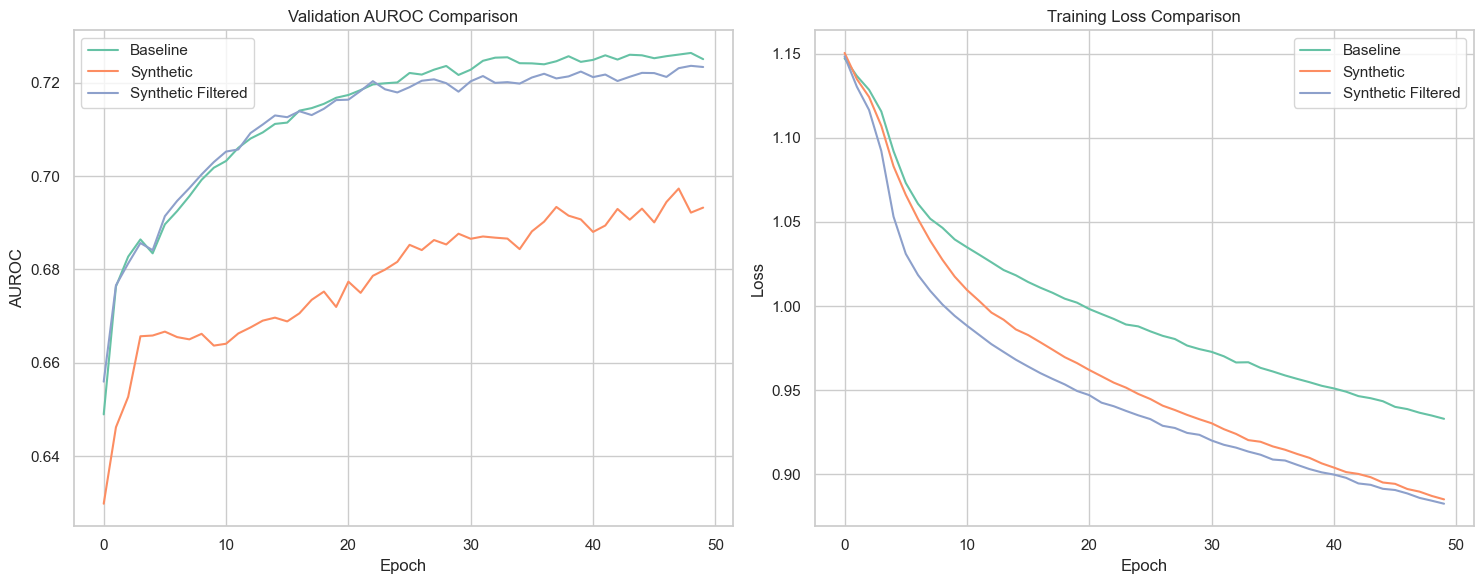

In [9]:
def load_training_logs(path):
    df = pd.read_csv(path)
    # PyTorch Lightning logs might have NaNs for metrics that are not logged every step
    # We aggregate by epoch to get a cleaner curve
    return df.groupby('epoch').mean().reset_index()

runs_root = '../classifier/runs'
df_baseline_train = load_training_logs(os.path.join(runs_root, 'baseline_slurm/version_0/metrics.csv'))
df_synthetic_train = load_training_logs(os.path.join(runs_root, 'synthetic_slurm/version_0/metrics.csv'))
df_filtered_train = load_training_logs(os.path.join(runs_root, 'synthetic_filtered_slurm/version_0/metrics.csv'))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Validation AUROC comparison
axes[0].plot(df_baseline_train['epoch'], df_baseline_train['val/auroc'], label='Baseline')
axes[0].plot(df_synthetic_train['epoch'], df_synthetic_train['val/auroc'], label='Synthetic')
axes[0].plot(df_filtered_train['epoch'], df_filtered_train['val/auroc'], label='Synthetic Filtered')
axes[0].set_title('Validation AUROC Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUROC')
axes[0].legend()

# Training Loss comparison
axes[1].plot(df_baseline_train['epoch'], df_baseline_train['train/loss'], label='Baseline')
axes[1].plot(df_synthetic_train['epoch'], df_synthetic_train['train/loss'], label='Synthetic')
axes[1].plot(df_filtered_train['epoch'], df_filtered_train['train/loss'], label='Synthetic Filtered')
axes[1].set_title('Training Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Best Epoch Performance
Detailed validation metrics for the best epoch of each run (based on mean validation AUROC).

In [ ]:
def get_best_epoch_metrics(df):
    best_epoch_idx = df['val/auroc'].idxmax()
    best_metrics = df.iloc[best_epoch_idx]
    return best_metrics

best_baseline = get_best_epoch_metrics(df_baseline_train)
best_synthetic = get_best_epoch_metrics(df_synthetic_train)
best_filtered = get_best_epoch_metrics(df_filtered_train)

pathology_cols = [c for c in df_baseline_train.columns if c.startswith('val/auroc_')]
pathology_names = [c.replace('val/auroc_', '') for c in pathology_cols]

best_comparison = pd.DataFrame({
    'Pathology': pathology_names,
    'Baseline': [best_baseline[c] for c in pathology_cols],
    'Synthetic': [best_synthetic[c] for c in pathology_cols],
    'Synthetic Filtered': [best_filtered[c] for c in pathology_cols]
}).set_index('Pathology')

# Add mean first (while models are still in columns)
best_comparison.loc['Mean'] = best_comparison.mean()

best_comparison = best_comparison.T

print("Validation AUROC at Best Epoch:")
display(best_comparison.style.highlight_max(axis=0, color='grey'))

Validation AUROC at Best Epoch:


Pathology,Brocho-pneumonia,Bronchiolitis,Bronchitis,No finding,Other disease,Pneumonia,Mean
Baseline,0.735886,0.676224,0.731072,0.729024,0.687235,0.798680,0.726353
Synthetic,0.712474,0.614620,0.668317,0.697125,0.685276,0.806068,0.697313
Synthetic Filtered,0.731919,0.651715,0.735581,0.725103,0.696564,0.800688,0.723595
